In [2]:
from qiskit import *

In [4]:
# Initializing quantum/Qiskit circuits
QuantumCircuit(2,2).draw()

q_0: 
     
q_1: 
     
c: 2/

this representation we can only see the names of the qubits and the bits that
we have created, for that is all that we have in our circuit so far

Qubits and classical bits in Qiskit are grouped in quantum and classical registers. By
default, when you create a circuit QuantumCircuit(n, m), Qiskit groups your qubits in
a quantum register q and your bits in a classical register c. You may however want to have a different arrangement of registers or you may want to give them different names. In order to do this, you can create your own registers, which will be objects of the QuantumRegister and ClassicalRegister classes. When initializing these registers, you are free to specify some size and name parameters. Once you have created some quantum and classical registers reg_1,. . . ,reg_n, you can stack them in a circuit with a call of the form QuantumCircuit(reg_1,...,reg_n).

In [3]:
qreg1 = QuantumRegister(size = 2, name = "qrg1")
qreg2 = QuantumRegister(1, "qrg2")
creg = ClassicalRegister(1, "oldschool")
qc = QuantumCircuit(qreg1, creg, qreg2)

qc.draw()

qrg1_0: 
             
     qrg1_1: 
             
       qrg2: 
             
oldschool: 1/

now have a circuit with a bunch of qubits. By default, all those qubits will be initialized to a state |0⟩

In [4]:
# Quantum gates
qc.x(0)

In [ ]:
# Pauli gates 𝑋, 𝑌 , or 𝑍

x(q0) # state gate flip, x = (0,1,1,0)
y(q0) #  phase shift and flips the qubit state, y = (0,-i,i,0)
z(q0) # phase flip, z = (1,0,0,-1)

# Hadamard gate - creates superposition state - qbits in multiple states at the same time
h(q0)

# Rotation gates 𝑅𝑋 , 𝑅𝑌 , or 𝑅𝑍 parametrized by theta
rx(theta,q0)
ry(theta,q0)
rz(theta,q0)

# universal one-qubit gate 𝑈(𝜃, 𝜑, 𝜆) parametrized by theta, phi, and lambda 
u(theta, phi, lambd, q0)


In [ ]:
# multi-qubit gates
# with control qubit 'q0' on a target 'qt' can be applied

cx(q0, qt) # controlled 𝑋 - CNOT gate
cy(q0, qt) # controlled 𝑌 
cz(q0, qt) # controlled 𝑍
ch(q0, qt) # controlled 𝐻 

# controlled rotation gate 𝑅𝑋 , 𝑅𝑌 , or 𝑅𝑍 parametrized by a value theta can be added

crx(theta, q0, qt)
cry(theta, q0, qt)
crz(theta, q0, qt)

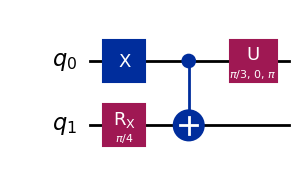

In [6]:
import numpy as np

qc0 = QuantumCircuit(2) # Initialise the circuit.

# We can now apply the gates sequentially.
qc0.x(0)
qc0.rx(np.pi/4, 1)
qc0.cx(0, 1)
qc0.u(np.pi/3, 0, np.pi, 0)

# now we run 
qc0.draw("mpl")

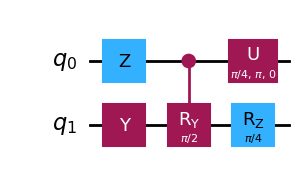

In [10]:
# practice for figure 2.3b
import numpy as np

qc0 = QuantumCircuit(2) # Initialise the circuit.

# We can now apply the gates sequentially.
qc0.z(0)  # qubit-0
qc0.y(1) # qubit-1

# Apply controlled-Rx(π/2) with qubit 0 as control, qubit 1 as target
qc0.cry(np.pi/2, 0, 1)


# qc0.cx(0, 1)
# qc0.ry(np.pi/2, 1)
qc0.u(np.pi/4, np.pi, 0, 0) # Apply U(π/4, π, 0) to qubit 0
qc0.rz(np.pi/4, 1)  # Apply Rz(π/4) to qubit 1

# now we run 
qc0.draw("mpl")

In [12]:
# Create a classical register with 2 bits
classical_reg = ClassicalRegister(2, 'c')

# Add the classical register to the circuit
qc0.add_register(classical_reg)

# Measure all qubits
qc0.measure_all()

# Display the circuit
print(qc0.draw())

        ┌───┐           ┌────────────┐ ░ ┌─┐   
   q_0: ┤ Z ├─────■─────┤ U(π/4,π,0) ├─░─┤M├───
        ├───┤┌────┴────┐└┬─────────┬─┘ ░ └╥┘┌─┐
   q_1: ┤ Y ├┤ Ry(π/2) ├─┤ Rz(π/4) ├───░──╫─┤M├
        └───┘└─────────┘ └─────────┘   ░  ║ └╥┘
   c: 2/══════════════════════════════════╬══╬═
                                          ║  ║ 
meas: 2/══════════════════════════════════╩══╩═
                                          0  1 


In [14]:
# Measure each qubit individually
qc0.measure(0, 0)  # Measure qubit 0 into classical bit 0
qc0.measure(1, 1)  # Measure qubit 1 into classical bit 1

# Display the circuit
print(qc0.draw())

        ┌───┐           ┌────────────┐ ░ ┌─┐   ┌─┐   
   q_0: ┤ Z ├─────■─────┤ U(π/4,π,0) ├─░─┤M├───┤M├───
        ├───┤┌────┴────┐└┬─────────┬─┘ ░ └╥┘┌─┐└╥┘┌─┐
   q_1: ┤ Y ├┤ Ry(π/2) ├─┤ Rz(π/4) ├───░──╫─┤M├─╫─┤M├
        └───┘└─────────┘ └─────────┘   ░  ║ └╥┘ ║ └╥┘
   c: 2/══════════════════════════════════╬══╬══╩══╩═
                                          ║  ║  0  1 
meas: 2/══════════════════════════════════╩══╩═══════
                                          0  1       


In [27]:
# Using Qiskit Aer to simulate quantum circuits
from qiskit_aer import AerSimulator
from qiskit.visualization import *

sim = AerSimulator()
sim_GPU = AerSimulator(device = 'GPU')

{'01': 528, '00': 496}


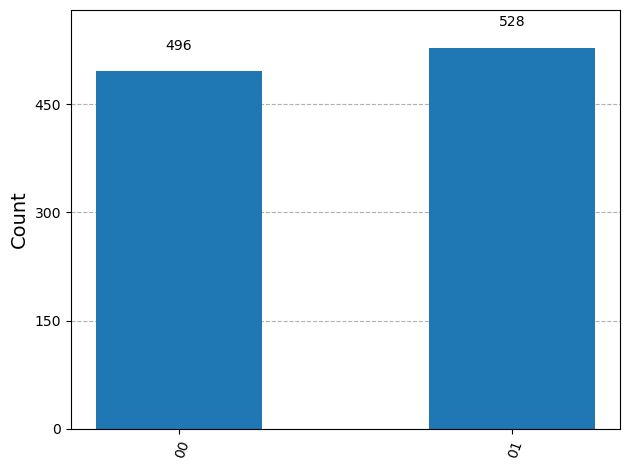

In [29]:
qc1 = QuantumCircuit(2, 2)
qc1.h(0)
qc1.measure(range(2), range(2))
#job = execute(qc, sim, shots = 1024) execute deprecated
job = sim.run(qc1, shots=1024)
result = job.result()
counts = result.get_counts()
print(counts)
plot_histogram(counts)

our circuits are simulated using the statevector method, which — as the name suggests — computes the exact quantum state (or state vector) of the system through the circuit in order to generate results.

In [33]:
# to access the state vector at any point in a quantum circuit qc,

qc2 = QuantumCircuit(2, 2)
qc2.h(0)
qc2.save_statevector()
qc2.measure(0,0)
qc2.measure(1,1)
#result = execute(qc, sim, shots = 1024).result()
#job = execute(qc, sim, shots = 1024) execute deprecated
job = sim.run(qc2, shots=1024)
result = job.result()
sv = result.get_statevector()
print(sv)
counts1 = result.get_counts()
print(counts1)

Statevector([0.70710678+0.j, 0.70710678+0.j, 0.        +0.j,
             0.        +0.j],
            dims=(2, 2))
{'00': 528, '01': 496}


computing the unitary matrix that would represent, up to any given point, the transformations that have been performed bythe circuit. In order to get this matrix

In [37]:
sim_u = AerSimulator(method = 'unitary')
qc3 = QuantumCircuit(1)
qc3.h(0)
qc3.save_unitary()

job = sim_u.run(qc3)
result = job.result()
U = result.get_unitary(decimals = 4)
print(U)

Operator([[ 0.7071+0.j,  0.7071-0.j],
          [ 0.7071+0.j, -0.7071+0.j]],
         input_dims=(2,), output_dims=(2,))


execution on real hardware, we get some outputs that should not even be allowed in the first place.
This is the effect of the noise of real quantum computers, which makes them deviate from perfect mathematical simulations.


When executing quantum circuits on actual quantum hardware, you have to be aware of the fact that real quantum systems only implement certain gates, and thus some of the gates that make up the circuit may have to be decomposed using the gates available. For instance, it is typical to decompose multi-qubit gates into qubits
that act on just one or two qubits or to simulate CNOT gates between qubits that are not directly connected in the quantum computer by first swapping the qubits, then applying an actually existing CNOT gate, and then swapping back the qubits.

This process is called transpilation, and, using the code that we have considered, we have let Qiskit take care of all its details automatically. However, it is possible to dive deeper into this and to hack it as much as one could want! For instance, you can use the transpile method to manually define a transpilation, specifying the gates that are present in the computer or the qubits that are actually connected, among other things.

Working with PennyLane

In [41]:
import pennylane as qml
# qml.__version__

'0.42.3'

In [ ]:
dev = qml.device('default.qubit', wires = 2)

def qc():
qml.PauliX(wires = 0) # qml.PauliX, qml.PauliY, and qml.PauliZ
qml.Hadamard(wires = 0)
return qml.state()

In [47]:
# Personal note

from pennylane import numpy as np
# create a quantum device

dev1 = qml.device( "default.qubit", wires=1)
@qml.qnode(dev1)

def circuit(phil, phi2):
    # a quantum node
    qml.RX(phil, wires=0)
    qml.RY(phi2, wires=0)
    return qml.expval(qml.PauliZ(0))

def cost(x, y):
    # classical processing
    return np.sin(np.abs(circuit(x, y))) - 1
    # calculate the gradient
    dcost = qml.grad(cost, argnum=[0, 1])
